# UV Effects 

# Loading

## Libraries

In [9]:
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.ts import train_and_evaluate_ts

## Data

In [10]:
# Load cancer datasets for each country : australia, uganda, usa, sweden, argentina

df_cancer_countries = {
    'Australia': pd.read_csv('data/countries/cancer/Australia.csv'),
    'Uganda': pd.read_csv('data/countries/cancer/Uganda.csv'),
    'USA': pd.read_csv('data/countries/cancer/USA.csv'),
    'Sweden': pd.read_csv('data/countries/cancer/Sweden.csv'),
    'Argentina': pd.read_csv('data/countries/cancer/Argentina.csv')    
}

df_uv_countries = {
    'Australia': pd.read_csv('data/countries/uv/Australia.csv'),
    'Uganda': pd.read_csv('data/countries/uv/Uganda.csv'),
    'USA': pd.read_csv('data/countries/uv/USA.csv'),
    'Sweden': pd.read_csv('data/countries/uv/Sweden.csv'),
    'Argentina': pd.read_csv('data/countries/uv/Argentina.csv')
}

# EDA

### Nulls

In [11]:
for country, df in df_cancer_countries.items():
    print(f"Nulls in {country}:")
    print(df.isnull().sum())
    print()

Nulls in Australia:
Cancer id          0
Cancer label       0
Population id      0
Country label      0
Sex                0
Type               0
Year               0
ASR (World)        0
Crude rate         0
Cumulative risk    0
Total              0
dtype: int64

Nulls in Uganda:
Cancer id          0
Cancer label       0
Population id      0
Country label      0
Sex                0
Type               0
Year               0
ASR (World)        0
Crude rate         0
Cumulative risk    0
Total              0
dtype: int64

Nulls in USA:
Cancer id          0
Cancer label       0
Population id      0
Country label      0
Sex                0
Type               0
Year               0
ASR (World)        0
Crude rate         0
Cumulative risk    0
Total              0
dtype: int64

Nulls in Sweden:
Cancer id          0
Cancer label       0
Population id      0
Country label      0
Sex                0
Type               0
Year               0
ASR (World)        0
Crude rate         0
Cumulati

In [13]:
# Create statistics for UV datasets
stats_data_uv = []
for country, df in df_uv_countries.items():
    stats = {
        'Country': country,
        'Avg UV Index': df['ALLSKY_SFC_UV_INDEX'].mean(),
        'Max UV Index': df['ALLSKY_SFC_UV_INDEX'].max(),
        'Min UV Index': df['ALLSKY_SFC_UV_INDEX'].min(),
        'Median UV Index': df['ALLSKY_SFC_UV_INDEX'].median(),
        'Std UV Index': df['ALLSKY_SFC_UV_INDEX'].std(),
        'Avg Temperature (°C)': df['T2M'].mean(),
        'Max Temperature (°C)': df['T2M'].max(),
        'Min Temperature (°C)': df['T2M'].min(),
        'Avg UVA': df['ALLSKY_SFC_UVA'].mean(),
        'Max UVA': df['ALLSKY_SFC_UVA'].max(),
        'Avg UVB': df['ALLSKY_SFC_UVB'].mean(),
        'Max UVB': df['ALLSKY_SFC_UVB'].max(),
        'Avg Solar Radiation': df['ALLSKY_SFC_SW_DWN'].mean(),
        'Max Solar Radiation': df['ALLSKY_SFC_SW_DWN'].max(),
        'Avg Ozone (TO3)': df['TO3'].mean(),
        'Min Ozone (TO3)': df['TO3'].min(),
        'Max Ozone (TO3)': df['TO3'].max(),
        'Avg Humidity (%)': df['RH2M'].mean(),
        'Total Precipitation': df['PRECTOTCORR'].sum(),
        'Avg Wind Speed (m/s)': df['WS10M'].mean(),
        'Number of Records': len(df),
        'Min Year': pd.to_datetime(df['Date']).dt.year.min(),
        'Max Year': pd.to_datetime(df['Date']).dt.year.max()
    }
    stats_data_uv.append(stats)

df_uv_stats = pd.DataFrame(stats_data_uv).set_index('Country').T

# Create a more visually appealing statistics table
df_uv_stats_formatted = df_uv_stats.copy()

# Round numeric values for better readability
numeric_rows = ['Avg UV Index', 'Max UV Index', 'Min UV Index', 'Median UV Index', 
                'Std UV Index', 'Avg Temperature (°C)', 'Max Temperature (°C)', 
                'Min Temperature (°C)', 'Avg UVA', 'Max UVA', 'Avg UVB', 'Max UVB',
                'Avg Solar Radiation', 'Max Solar Radiation', 'Avg Ozone (TO3)', 
                'Min Ozone (TO3)', 'Max Ozone (TO3)', 'Avg Humidity (%)', 
                'Total Precipitation', 'Avg Wind Speed (m/s)', 'Number of Records', 
                'Min Year', 'Max Year']

for row in numeric_rows:
    if row in ['Total Precipitation', 'Number of Records', 'Min Year', 'Max Year']:
        df_uv_stats_formatted.loc[row] = df_uv_stats_formatted.loc[row].apply(lambda x: f"{int(x)}")
    else:
        df_uv_stats_formatted.loc[row] = df_uv_stats_formatted.loc[row].apply(lambda x: f"{float(x):.2f}")

# Style the dataframe
styled_table = df_uv_stats_formatted.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border-color': 'black',
    'border-width': '1px',
    'border-style': 'solid'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#2F4330"), 
                                  ('color', 'white'), 
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '8px')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
])

display(styled_table)

Country,Australia,Uganda,USA,Sweden,Argentina
Avg UV Index,2.34,2.30,1.18,0.44,1.50
Max UV Index,11.31,3.48,3.42,1.86,4.47
Min UV Index,0.22,0.56,0.05,0.00,0.09
Median UV Index,2.32,2.34,1.06,0.27,1.28
Std UV Index,1.04,0.40,0.76,0.46,0.97
Avg Temperature (°C),21.10,24.22,13.32,2.53,16.57
Max Temperature (°C),38.92,31.16,36.65,22.88,33.00
Min Temperature (°C),4.67,18.80,-22.63,-36.38,0.20
Avg UVA,0.40,0.35,0.26,0.15,0.29
Max UVA,0.62,0.47,0.52,0.46,0.55


## Preprcessing

In [14]:
# Create statistics for cancer datasets
stats_data_cancer = []
for country, df in df_cancer_countries.items():
    stats = {
        'Country': country,
        'Avg ASR (World)': df['ASR (World)'].mean(),
        'Max ASR (World)': df['ASR (World)'].max(),
        'Min ASR (World)': df['ASR (World)'].min(),
        'Median ASR (World)': df['ASR (World)'].median(),
        'Std ASR (World)': df['ASR (World)'].std(),
        'Avg Crude rate': df['Crude rate'].mean(),
        'Max Crude rate': df['Crude rate'].max(),
        'Min Crude rate': df['Crude rate'].min(),
        'Avg Cumulative risk': df['Cumulative risk'].mean(),
        'Max Cumulative risk': df['Cumulative risk'].max(),
        'Min Cumulative risk': df['Cumulative risk'].min(),
        'Total Cases': df['Total'].sum(),
        'Avg Total': df['Total'].mean(),
        'Max Total': df['Total'].max(),
        'Min Total': df['Total'].min(),
        'Number of Records': len(df),
        'Min Year': df['Year'].min(),
        'Max Year': df['Year'].max(),
        'Number of Cancer Types': df['Cancer label'].nunique(),
        'Number of Years': df['Year'].nunique()
    }
    stats_data_cancer.append(stats)

df_cancer_stats = pd.DataFrame(stats_data_cancer).set_index('Country').T

# Create a more visually appealing statistics table
df_cancer_stats_formatted = df_cancer_stats.copy()

# Round numeric values for better readability
numeric_rows_cancer = ['Avg ASR (World)', 'Max ASR (World)', 'Min ASR (World)', 'Median ASR (World)', 
                       'Std ASR (World)', 'Avg Crude rate', 'Max Crude rate', 'Min Crude rate', 
                       'Avg Cumulative risk', 'Max Cumulative risk', 'Min Cumulative risk', 
                       'Total Cases', 'Avg Total', 'Max Total', 'Min Total', 'Number of Records', 
                       'Min Year', 'Max Year', 'Number of Cancer Types', 'Number of Years']

for row in numeric_rows_cancer:
    if row in ['Total Cases', 'Number of Records', 'Min Year', 'Max Year', 'Max Total', 'Min Total', 'Number of Cancer Types', 'Number of Years']:
        df_cancer_stats_formatted.loc[row] = df_cancer_stats_formatted.loc[row].apply(lambda x: f"{int(x)}")
    else:
        df_cancer_stats_formatted.loc[row] = df_cancer_stats_formatted.loc[row].apply(lambda x: f"{float(x):.2f}")

# Style the dataframe
styled_table_cancer = df_cancer_stats_formatted.style.set_properties(**{
    'text-align': 'center',
    'font-size': '11pt',
    'border-color': 'black',
    'border-width': '1px',
    'border-style': 'solid'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#2F4330"), 
                                  ('color', 'white'), 
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '8px')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
])

display(styled_table_cancer)

Country,Australia,Uganda,USA,Sweden,Argentina
Avg ASR (World),125.88,59.19,120.82,7.78,75.16
Max ASR (World),329.95,207.64,334.57,9.25,225.15
Min ASR (World),25.21,0.24,8.33,3.94,1.95
Median ASR (World),34.06,3.71,42.18,8.40,14.71
Std ASR (World),135.62,81.27,134.65,1.47,95.20
Avg Crude rate,196.17,23.42,173.64,14.94,90.91
Max Crude rate,559.91,78.86,486.59,19.00,268.07
Min Crude rate,38.16,0.07,9.71,6.88,2.24
Avg Cumulative risk,12.61,6.30,12.33,0.87,7.84
Max Cumulative risk,32.01,22.61,33.00,1.01,22.98


# Comparisons

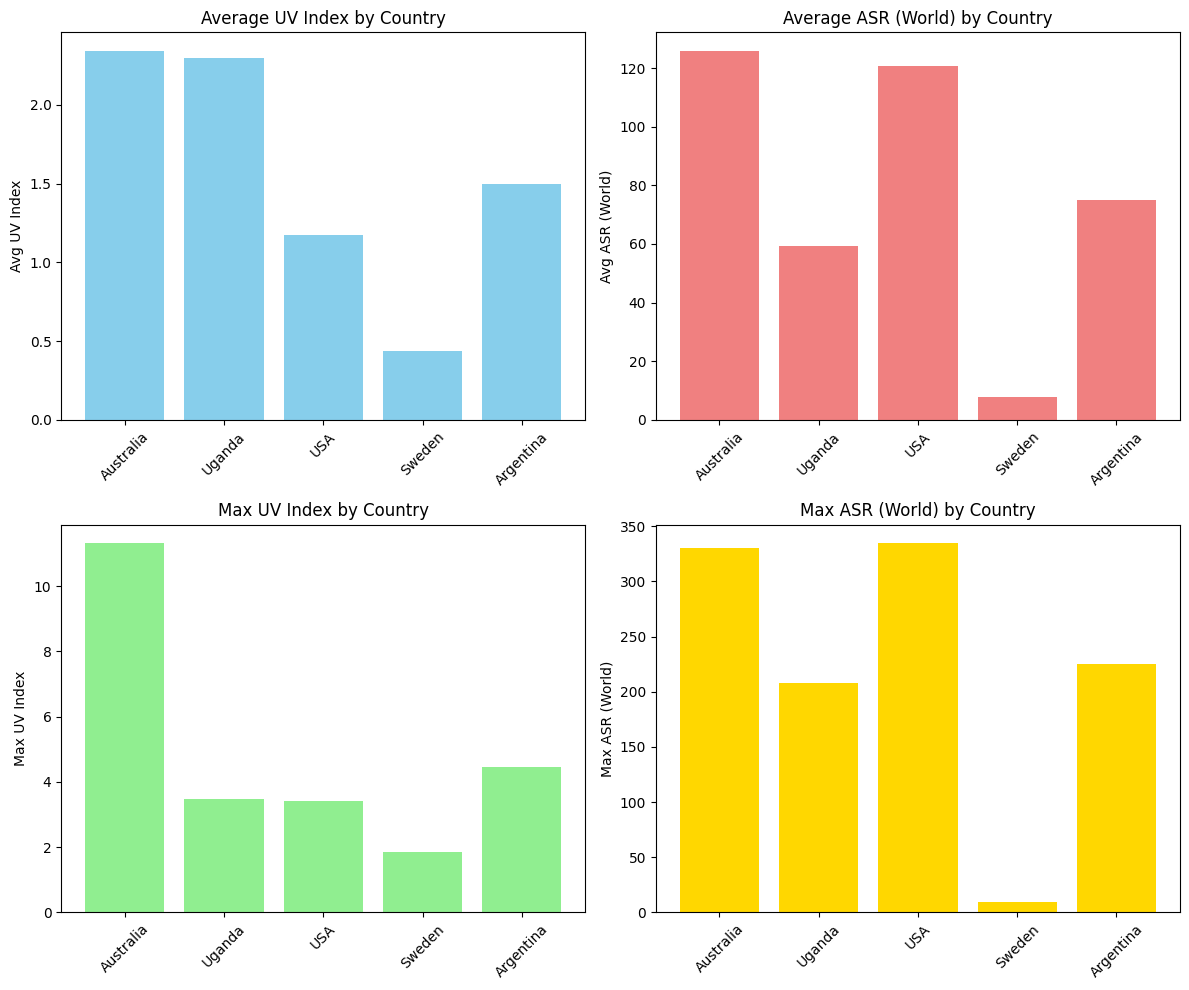

In [15]:
import matplotlib.pyplot as plt

# Extract data for plotting
countries = df_uv_stats.columns.tolist()
avg_uv = df_uv_stats.loc['Avg UV Index'].values
max_uv = df_uv_stats.loc['Max UV Index'].values
avg_asr = df_cancer_stats.loc['Avg ASR (World)'].values
max_asr = df_cancer_stats.loc['Max ASR (World)'].values

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top left: Bar plot for Avg UV Index
axes[0, 0].bar(countries, avg_uv, color='skyblue')
axes[0, 0].set_title('Average UV Index by Country')
axes[0, 0].set_ylabel('Avg UV Index')
axes[0, 0].tick_params(axis='x', rotation=45)

# Top right: Bar plot for Avg ASR (World)
axes[0, 1].bar(countries, avg_asr, color='lightcoral')
axes[0, 1].set_title('Average ASR (World) by Country')
axes[0, 1].set_ylabel('Avg ASR (World)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Bottom left: Bar plot for Max UV Index
axes[1, 0].bar(countries, max_uv, color='lightgreen')
axes[1, 0].set_title('Max UV Index by Country')
axes[1, 0].set_ylabel('Max UV Index')
axes[1, 0].tick_params(axis='x', rotation=45)

# Bottom right: Bar plot for Max ASR (World)
axes[1, 1].bar(countries, max_asr, color='gold')
axes[1, 1].set_title('Max ASR (World) by Country')
axes[1, 1].set_ylabel('Max ASR (World)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

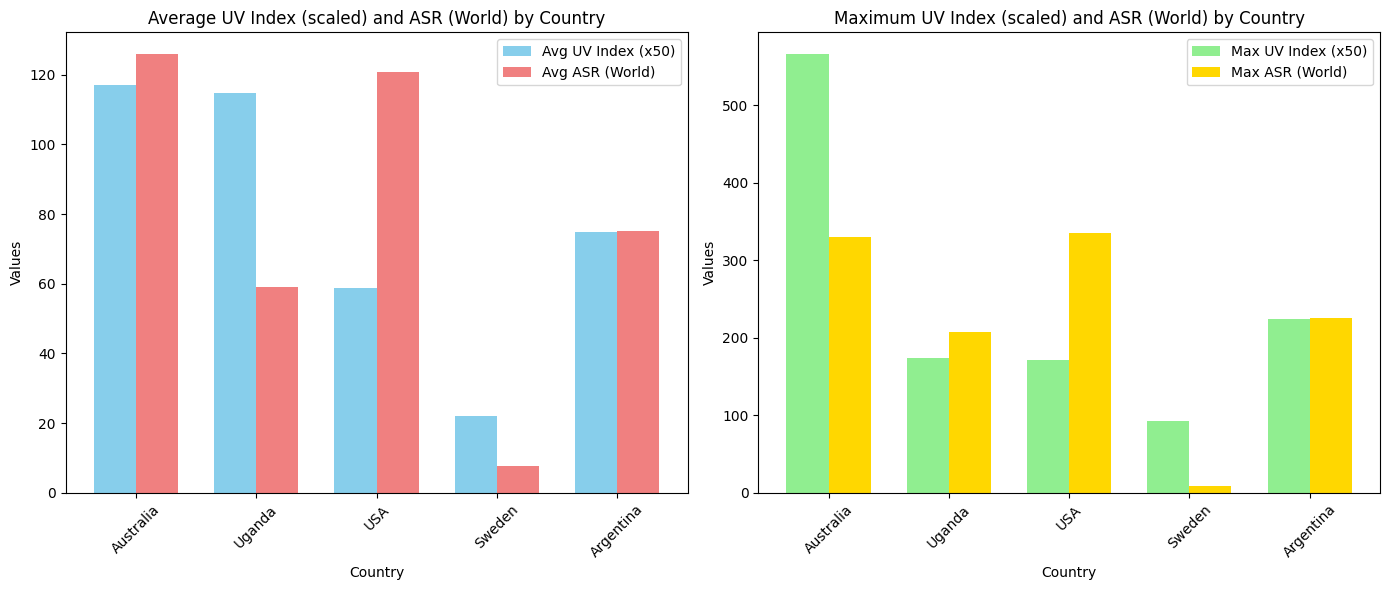

In [ ]:
# Data for averages
avg_uv = df_uv_stats.loc['Avg UV Index'].values
avg_asr = df_cancer_stats.loc['Avg ASR (World)'].values

# Data for maximums
max_uv = df_uv_stats.loc['Max UV Index'].values
max_asr = df_cancer_stats.loc['Max ASR (World)'].values

countries = df_uv_stats.columns.tolist()

# Scale UV values by 50 for better visibility
scale_factor = 50
avg_uv_scaled = avg_uv * scale_factor
max_uv_scaled = max_uv * scale_factor

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for averages
x = np.arange(len(countries))  # the label locations
width = 0.35  # the width of the bars

axes[0].bar(x - width/2, avg_uv_scaled, width, label=f'Avg UV Index (x{scale_factor})', color='skyblue')
axes[0].bar(x + width/2, avg_asr, width, label='Avg ASR (World)', color='lightcoral')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Values')
axes[0].set_title('Average UV Index (scaled) and ASR (World) by Country')
axes[0].set_xticks(x)
axes[0].set_xticklabels(countries, rotation=45)
axes[0].legend()

# Plot for maximums
axes[1].bar(x - width/2, max_uv_scaled, width, label=f'Max UV Index (x{scale_factor})', color='lightgreen')
axes[1].bar(x + width/2, max_asr, width, label='Max ASR (World)', color='gold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Values')
axes[1].set_title('Maximum UV Index (scaled) and ASR (World) by Country')
axes[1].set_xticks(x)
axes[1].set_xticklabels(countries, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()